# Maximum Observing Night at CTAO-North — Full Year 2027

For each calendar day of 2027, this notebook computes the **maximum observing night**:
the fraction of the astronomical night (Sun altitude < −18°) that remains after subtracting
intervals during which the Moon raises the sky-background rate above the downtime threshold.

| Parameter | Value |
|---|---|
| Site | CTAO-North, La Palma (lon = −17.892°, lat = +28.762°, alt = 2200 m) |
| Instrument | LST-1 (LSTCam, La Palma) |
| Night definition | Astronomical twilight: Sun altitude < −18° |
| Dark-sky baseline B_dark | Mean of 12 azimuths at alt = 70°: nsb2 airglow (ESO SkyCalc) + Gaia DR3 stellar map, new Moon |
| Dark sky condition | Total NSB < 1.25 × B_dark |
| Downtime threshold | Total NSB > 11 × B_dark |
| Reference pointing | Fixed high-altitude direction (alt = 70°, az = 0°); conservative estimate |
| Time sampling | 10-minute steps |
| Parallelism | ThreadPoolExecutor (up to 8 workers) |
| Output file | `ctao_north_max_observing_night_2027.csv` |

> **Note on conservatism.** A fixed pointing does not optimise for the anti-Moon direction.
> The true maximum observing fraction is therefore slightly higher than reported here,
> because pointing away from the Moon reduces scattered moonlight.


In [1]:
import os
import warnings
import multiprocessing
from concurrent.futures import ProcessPoolExecutor, as_completed

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import astropy.coordinates
import astropy.units as u
from astropy.coordinates import AltAz, SkyCoord, SkyOffsetFrame, get_body, get_sun
from astropy.time import Time
from astropy.utils.exceptions import AstropyWarning
from tqdm.auto import tqdm

from nsb2.atmosphere import SingleScatteringAtmosphere
from nsb2.core.lightpath import DirectPath, ScatteredPath
from nsb2.core.pipeline import Pipeline
from nsb2.core.solver import LUTDirectSolver, LUTScatteredSolver
from nsb2.emitter import airglow, moon, stars
from nsb2.instrument import CTAO

warnings.filterwarnings("ignore", category=AstropyWarning)


/home/sspencer/miniforge3/envs/nsb2-dev/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Site, Instrument and Atmosphere

In [2]:

# CTAO-North coordinates from the official site description
LOCATION = astropy.coordinates.EarthLocation.from_geodetic(
    lon=-17.89200500 * u.deg,
    lat=28.76216678 * u.deg,
    height=2200 * u.m,
)

# LST-1 — the Large-Sized Telescope at La Palma, CTAO-North.
instrument = CTAO.LST1North()


def create_atmosphere() -> SingleScatteringAtmosphere:
    """Standard La Palma single-scattering atmosphere (from generate_time_series.py)."""

    def X(Z):
        return 1 / (np.cos(Z) + 0.50572 * (96.07995 - np.rad2deg(Z)) ** (-1.6364))

    return SingleScatteringAtmosphere(
        X,
        lambda lam: 0.00879 * lam.to(u.micron).value ** -4.09 * np.exp(-8.0 / 8.0),
        lambda lam: 0.5 * (lam.to(u.nm).value / 380) ** (-1.0) * np.exp(-1.8 / 1.54),
        lambda lam: np.zeros(lam.shape),
        0.8,
    )


atmosphere = create_atmosphere()
print("Site, instrument (LST-1), and atmosphere ready.")


Site, instrument (LST-1), and atmosphere ready.


## Dark-Sky Baseline: Compile Airglow + Stars Pipeline

The dark-sky baseline B_dark is derived from the nsb2 ESO-SkyCalc airglow model
(Noll et al. 2012) plus the pre-binned Gaia DR3 diffuse stellar background map
(`stars.from_gaia_dr3_map()`, stars fainter than the catalog split magnitude),
evaluated at the reference pointing (alt = 70°) during the first new Moon of 2027.

The stellar map is a HEALPix diffuse source compiled identically to airglow — no
per-step cost is added to the main loop. Its variation with pointing across the year
is neglected; only its new-Moon reference level is used to set the threshold.

The rejection threshold is set to **11 × B_dark** in pipeline units (GHz per pixel).


In [3]:

glow = airglow.from_eso_skycalc(87 * u.km, 100)
# Faint-star diffuse background (Gaia DR3, cached after first download)
star_map = stars.from_gaia_dr3_map()

dark_pipeline = Pipeline(
    instrument,
    atmosphere,
    [glow, star_map],
    paths=[DirectPath(solver=LUTDirectSolver())],
)
print("Compiling dark-sky (airglow + stars) pipeline …", end=" ", flush=True)
dark_pipeline.compile(extinction_z_bins=45)
print("done.")

# Evaluate on the first new Moon of 2027 (2027-01-14).
# Sample 12 equally-spaced azimuths at alt=70° to average over galactic longitude
# and obtain a representative sky-average B_dark rather than a single-pointing value.
_t_ref = Time("2027-01-14T06:00:00", format="isot", scale="utc")
_base_ref = AltAz(
    obstime=_t_ref,
    location=LOCATION,
    pressure=1000 * u.hPa,
    relative_humidity=0.3,
    temperature=20 * u.deg_C,
)

_N_AZ = 12
_dark_medians = []
for _az in np.linspace(0, 360 * (1 - 1 / _N_AZ), _N_AZ):
    _coord = SkyCoord(alt=70 * u.deg, az=_az * u.deg, frame=_base_ref)
    _obs = SkyOffsetFrame(origin=_coord, rotation=0 * u.deg)
    _preds = dark_pipeline.predict(_obs)
    _rates = np.sum([p.rates.to(u.GHz)[:, 1].value for p in _preds], axis=0)
    _dark_medians.append(float(np.median(_rates)))

B_DARK_GHz = float(np.mean(_dark_medians))

# Rejection threshold: total NSB > 11 × dark-sky rate
THRESHOLD_GHz = 11.0 * B_DARK_GHz
# Dark sky threshold: total NSB < 1.25 × dark-sky rate
DARK_SKY_THRESHOLD_GHz = 1.25 * B_DARK_GHz

print(f"\nDark-sky rate (airglow + stars, {_N_AZ} azimuths, alt=70°): {B_DARK_GHz:.4f} GHz / pixel")
print(f"  azimuth spread: {min(_dark_medians):.4f} – {max(_dark_medians):.4f} GHz / pixel")
print(f"Dark sky threshold (1.25 × B_dark):                        {DARK_SKY_THRESHOLD_GHz:.4f} GHz / pixel")
print(f"Rejection threshold (11 × B_dark):                         {THRESHOLD_GHz:.4f} GHz / pixel")



Compiling dark-sky (airglow + stars) pipeline … done.

Dark-sky rate (airglow + stars, 12 azimuths, alt=70°): 0.1574 GHz / pixel
  azimuth spread: 0.1573 – 0.1575 GHz / pixel
Dark sky threshold (1.25 × B_dark):                        0.1968 GHz / pixel
Rejection threshold (11 × B_dark):                         1.7316 GHz / pixel


## Moon Pipeline: Compile Once

A moon-only pipeline is compiled once using the Noll 2013 ROLO model.
Coarser LUT bins are used to reduce compilation and evaluation time;
accuracy is sufficient for a ±10-min downtime estimate.

In [4]:
noll13 = moon.from_noll2013()

moon_pipeline = Pipeline(
    instrument,
    atmosphere,
    [noll13],
    paths=[
        DirectPath(solver=LUTDirectSolver()),
        ScatteredPath(solver=LUTScatteredSolver()),
    ],
)
print("Compiling moon pipeline …", end=" ", flush=True)
moon_pipeline.compile(
    extinction_z_bins=45,
    scattering_z_bins=8,
    scattering_theta_bins=8,
)
print("done.")

Compiling moon pipeline … done.


## Helper Functions

In [5]:
def find_astronomical_night(
    date_str: str,
    location,
    sun_alt_deg: float = -18.0,
    dt_min: float = 5.0,
):
    """Return (night_start, night_end) for the astronomical night on date_str.

    Searches the 24-hour window starting at local noon on date_str.
    Returns (None, None) when no astronomical night exists.
    """
    noon = Time(date_str + "T12:00:00", format="isot", scale="utc")
    n_steps = int(24 * 60 / dt_min) + 1
    times = noon + np.arange(n_steps) * dt_min * u.min

    altaz = AltAz(obstime=times, location=location)
    sun_alt = get_sun(times).transform_to(altaz).alt.deg

    below = sun_alt < sun_alt_deg
    if not np.any(below):
        return None, None

    idx = np.where(below)[0]
    return times[idx[0]], times[idx[-1]]


def make_reference_obs(obstime, location):
    """Observation frame at fixed reference direction (alt=70°, az=0°)."""
    base = AltAz(
        obstime=obstime,
        location=location,
        pressure=1000 * u.hPa,
        relative_humidity=0.3,
        temperature=20 * u.deg_C,
    )
    target = SkyCoord(alt=70 * u.deg, az=0 * u.deg, frame=base)
    return SkyOffsetFrame(origin=target, rotation=0 * u.deg)


def moon_rate_GHz(obstime, location) -> float:
    """Median per-pixel moon NSB rate [GHz] at the reference pointing."""
    obs = make_reference_obs(obstime, location)
    preds = moon_pipeline.predict(obs)
    rates = np.sum([p.rates.to(u.GHz)[:, 1].value for p in preds], axis=0)
    return float(np.median(rates))


def process_day(date_str: str) -> dict:
    """Compute the maximum observing night record for one calendar day."""
    t_start, t_end = find_astronomical_night(date_str, LOCATION, SUN_ALT_DEG)

    if t_start is None:
        return dict(
            date=date_str,
            night_start_utc="",
            night_end_utc="",
            night_duration_h=0.0,
            moon_downtime_h=0.0,
            max_observing_fraction=float("nan"),
            dark_sky_fraction=float("nan"),
        )

    night_h = (t_end - t_start).to(u.hour).value
    n = max(2, int(round(night_h * 60 / SAMPLING_MIN)))
    sample_times = t_start + np.linspace(0.0, night_h, n) * u.hour
    # Each of the n samples represents an equal share of the night
    dt_h = night_h / n

    moon_down_h = 0.0
    dark_sky_h = 0.0
    for t in sample_times:
        # Fast pre-check: skip pipeline when Moon is below the horizon.
        moon_alt = (
            get_body("moon", t)
            .transform_to(AltAz(obstime=t, location=LOCATION))
            .alt.deg
        )
        if moon_alt < 0.0:
            # No moon contribution: total NSB = B_dark (always dark sky)
            dark_sky_h += dt_h
            continue

        r_moon = moon_rate_GHz(t, LOCATION)
        total_nsb = r_moon + B_DARK_GHz
        if total_nsb > THRESHOLD_GHz:
            moon_down_h += dt_h
        elif total_nsb < DARK_SKY_THRESHOLD_GHz:
            dark_sky_h += dt_h

    max_frac = max(0.0, (night_h - moon_down_h) / night_h)
    dark_frac = dark_sky_h / night_h
    return dict(
        date=date_str,
        night_start_utc=t_start.iso,
        night_end_utc=t_end.iso,
        night_duration_h=round(night_h, 3),
        moon_downtime_h=round(moon_down_h, 3),
        max_observing_fraction=round(max_frac, 4),
        dark_sky_fraction=round(dark_frac, 4),
    )


print("Helper functions defined.")


Helper functions defined.


## Main Computation: 365 Nights of 2027

For each day, we:
1. Find the astronomical night boundaries (Sun altitude < −18°).
2. Sample every **10 minutes**.
3. Skip the pipeline call when the Moon is below the horizon (zero contribution).
4. Compare the **total NSB** (moon contribution + dark-sky baseline B_dark) to the
   rejection threshold of **11 × B_dark**; declare downtime when exceeded.
5. Accumulate the observable and downtime intervals.

Days are processed in **parallel** using `ProcessPoolExecutor` with `fork`-based
worker processes. Each worker inherits the compiled pipeline objects from the parent
process, so no recompilation is needed. True CPU parallelism is achieved because each
process has its own GIL.

Expected runtime: approximately 10–20 minutes with 8 worker processes.


In [6]:

YEAR = 2027
SAMPLING_MIN = 10
SUN_ALT_DEG = -18.0
N_WORKERS = min(8, os.cpu_count() or 1)

t0 = Time(f"{YEAR}-01-01T00:00:00", format="isot", scale="utc")
date_strings = [(t0 + i * u.day).iso[:10] for i in range(365)]

print(f"Processing {len(date_strings)} nights with {N_WORKERS} worker processes …")

# fork inherits compiled pipelines; spawn would require re-pickling them
_mp_ctx = multiprocessing.get_context("fork")
records = [None] * len(date_strings)
with ProcessPoolExecutor(max_workers=N_WORKERS, mp_context=_mp_ctx) as executor:
    future_to_idx = {
        executor.submit(process_day, ds): i
        for i, ds in enumerate(date_strings)
    }
    for future in tqdm(as_completed(future_to_idx), total=len(date_strings),
                       desc=f"CTAO-North {YEAR}"):
        records[future_to_idx[future]] = future.result()

print("Computation complete.")



Processing 365 nights with 8 worker processes …


CTAO-North 2027: 100%|██████████| 365/365 [04:44<00:00,  1.28it/s]

Computation complete.


## Save Results to CSV

In [7]:
df = pd.DataFrame(records)

output_path = "ctao_north_max_observing_night_2027.csv"
df.to_csv(output_path, index=False, float_format="%.4f")
print(f"Saved {len(df)} rows to {output_path}")

# Print summary statistics
valid = df[df["max_observing_fraction"].notna()]
print(f"\nYear summary ({YEAR}):")
print(f"  Nights with astronomical night: {len(valid)}")
print(f"  Mean night duration:            {valid['night_duration_h'].mean():.2f} h")
print(f"  Mean moon downtime:             {valid['moon_downtime_h'].mean():.2f} h")
print(f"  Mean max observing fraction:    {valid['max_observing_fraction'].mean():.3f}")
print(f"  Mean dark sky fraction:         {valid['dark_sky_fraction'].mean():.3f}")
print(f"  Nights with fraction = 1.0:     {(valid['max_observing_fraction'] == 1.0).sum()}")
print(f"  Nights with fraction = 0.0:     {(valid['max_observing_fraction'] == 0.0).sum()}")
print()
print(df[["date", "night_duration_h", "moon_downtime_h", "max_observing_fraction", "dark_sky_fraction"]].to_string(index=False))


Saved 365 rows to ctao_north_max_observing_night_2027.csv

Year summary (2027):
  Nights with astronomical night: 365
  Mean night duration:            8.95 h
  Mean moon downtime:             1.17 h
  Mean max observing fraction:    0.879
  Mean dark sky fraction:         0.562
  Nights with fraction = 1.0:     290
  Nights with fraction = 0.0:     7

      date  night_duration_h  moon_downtime_h  max_observing_fraction  dark_sky_fraction
2027-01-01            10.833            0.000                  1.0000             0.9077
2027-01-02            10.750            0.000                  1.0000             1.0000
2027-01-03            10.750            0.000                  1.0000             1.0000
2027-01-04            10.750            0.000                  1.0000             1.0000
2027-01-05            10.750            0.000                  1.0000             1.0000
2027-01-06            10.750            0.000                  1.0000             1.0000
2027-01-07            

## Summary Plot

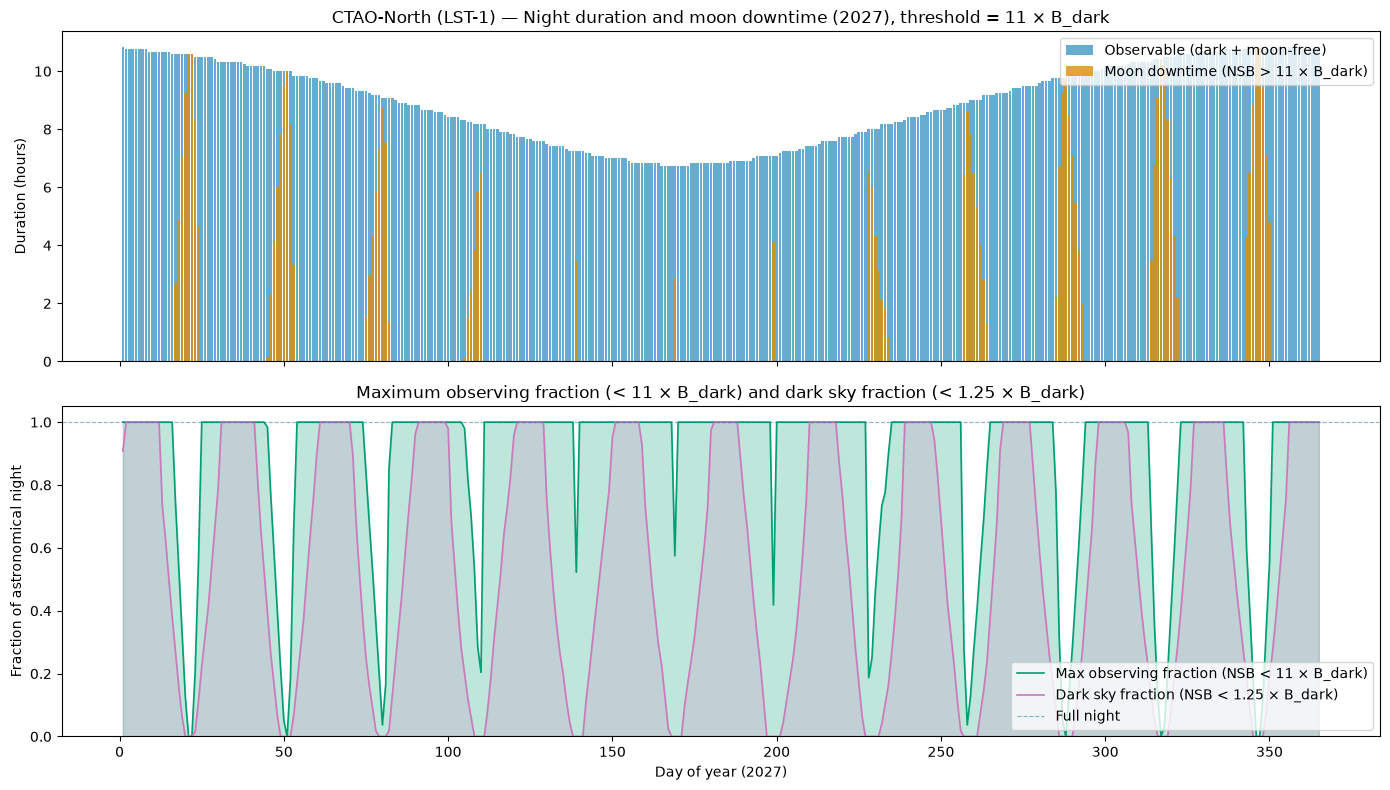

Plot saved to ctao_north_max_observing_night_2027.png


In [8]:
valid = df[df["max_observing_fraction"].notna()].copy()
doy = np.arange(1, len(valid) + 1)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top panel: night duration stacked with downtime
axes[0].bar(
    doy,
    valid["night_duration_h"],
    color="#0173B2",
    alpha=0.6,
    label="Observable (dark + moon-free)",
)
axes[0].bar(
    doy,
    valid["moon_downtime_h"],
    color="#DE8F05",
    alpha=0.8,
    label="Moon downtime (NSB > 11 × B_dark)",
)
axes[0].set_ylabel("Duration (hours)")
axes[0].set_title(
    f"CTAO-North (LST-1) — Night duration and moon downtime ({YEAR}), "
    "threshold = 11 × B_dark"
)
axes[0].legend(loc="upper right")
axes[0].set_ylim(0, None)

# Bottom panel: maximum observing fraction and dark sky fraction
axes[1].plot(doy, valid["max_observing_fraction"], color="#029E73", lw=1.2,
             label="Max observing fraction (NSB < 11 × B_dark)")
axes[1].fill_between(doy, valid["max_observing_fraction"], alpha=0.25, color="#029E73")
axes[1].plot(doy, valid["dark_sky_fraction"], color="#CC78BC", lw=1.2,
             label="Dark sky fraction (NSB < 1.25 × B_dark)")
axes[1].fill_between(doy, valid["dark_sky_fraction"], alpha=0.20, color="#CC78BC")
axes[1].axhline(1.0, color="#0173B2", ls="--", lw=0.8, alpha=0.5, label="Full night")
axes[1].set_ylabel("Fraction of astronomical night")
axes[1].set_xlabel(f"Day of year ({YEAR})")
axes[1].set_ylim(0, 1.05)
axes[1].set_title(
    "Maximum observing fraction (< 11 × B_dark) and dark sky fraction (< 1.25 × B_dark)"
)
axes[1].legend(loc="lower right")

plt.tight_layout()
fig.savefig("ctao_north_max_observing_night_2027.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to ctao_north_max_observing_night_2027.png")


## NSB Rate as a Multiple of the Dark-Sky Baseline

One pipeline call per night (at the midpoint of the astronomical night) is enough to show
the lunar cycle across the year. The orange shading marks intervals where the moon drives
the NSB above the 11 × B_dark downtime threshold.


Midpoint NSB: 100%|██████████| 365/365 [00:42<00:00,  8.64it/s]


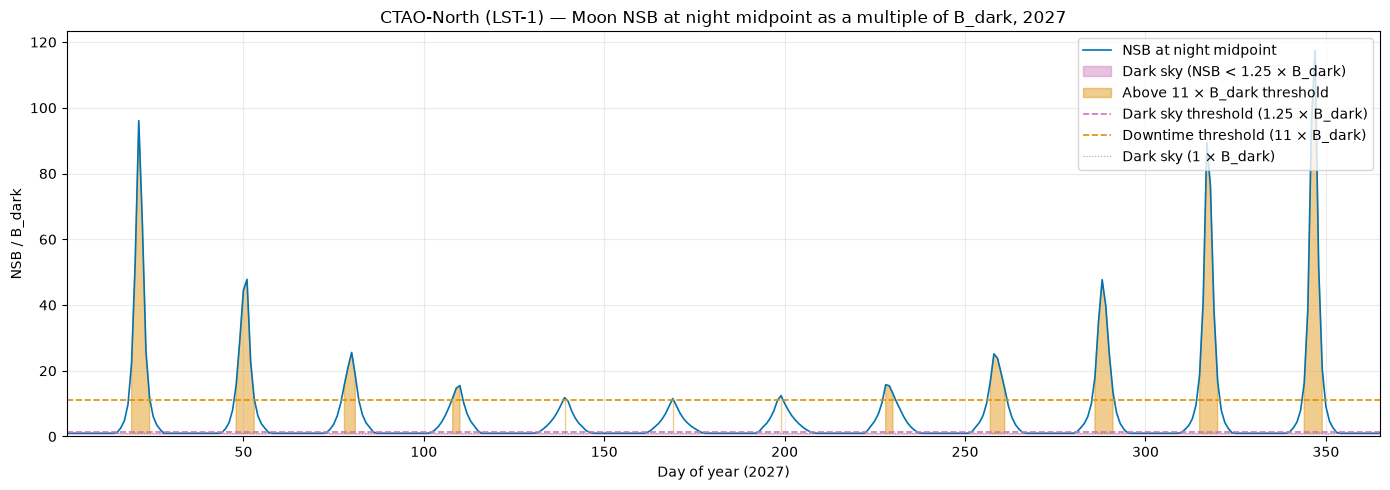

Saved ctao_north_nsb_multiple_2027.png


In [9]:

# One pipeline call per night at the midpoint — fast and sufficient for the year view.
_midpoint_multiples = []
for rec in tqdm(records, desc="Midpoint NSB"):
    if not rec["night_start_utc"]:
        _midpoint_multiples.append(np.nan)
        continue
    t_mid = (
        Time(rec["night_start_utc"], format="iso", scale="utc")
        + (rec["night_duration_h"] / 2) * u.hour
    )
    moon_alt = (
        get_body("moon", t_mid)
        .transform_to(AltAz(obstime=t_mid, location=LOCATION))
        .alt.deg
    )
    r_moon = moon_rate_GHz(t_mid, LOCATION) if moon_alt >= 0.0 else 0.0
    _midpoint_multiples.append((r_moon + B_DARK_GHz) / B_DARK_GHz)

_doy = np.arange(1, len(records) + 1)
_mult = np.array(_midpoint_multiples, dtype=float)

fig2, ax = plt.subplots(figsize=(14, 5))

ax.plot(_doy, _mult, color="#0173B2", lw=1.2, label="NSB at night midpoint")
ax.fill_between(_doy, 1.0, np.where(np.nan_to_num(_mult) <= 1.25, _mult, 1.0),
                color="#CC78BC", alpha=0.45, label="Dark sky (NSB < 1.25 × B_dark)")
ax.fill_between(_doy, 1.0, _mult,
                where=np.nan_to_num(_mult) > 11.0,
                color="#DE8F05", alpha=0.45, label="Above 11 × B_dark threshold")
ax.axhline(1.25, color="#CC78BC", ls="--", lw=1.2, label="Dark sky threshold (1.25 × B_dark)")
ax.axhline(11.0, color="#DE8F05", ls="--", lw=1.2, label="Downtime threshold (11 × B_dark)")
ax.axhline(1.0, color="gray", ls=":", lw=0.8, alpha=0.7, label="Dark sky (1 × B_dark)")
ax.set_xlabel(f"Day of year ({YEAR})")
ax.set_ylabel("NSB / B_dark")
ax.set_title(
    f"CTAO-North (LST-1) — Moon NSB at night midpoint as a multiple of B_dark, {YEAR}"
)
ax.set_xlim(1, 365)
ax.set_ylim(0, None)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.25)

plt.tight_layout()
fig2.savefig("ctao_north_nsb_multiple_2027.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ctao_north_nsb_multiple_2027.png")

